# Climate-watch notebook 
datascience case

1. Create database 
2. Creat jupyter notebook
3. Clean database
4. Assignements
5. Power BI

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import sqlalchemy as SA
import numpy as np
import random as rand
import plotly.express as px

In [2]:
# connect to database
engine = SA.create_engine("mysql+pymysql://root@localhost/climate_watch?charset=utf8mb4")

In [3]:
sql = "SELECT * FROM globaltemperatures"
df = pd.read_sql(sql, engine)
df.head()

,id,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
inspector = SA.inspect(engine)
table_names = inspector.get_table_names()

table_names
for table in table_names:
    print(f'{table}')
    columns = inspector.get_columns(table)
    for col in columns:
        print(f"   {col['name']}")

city
   id
   name
   country_id
country
   id
   name
globaltempcity
   id
   dt
   AverageTemperature
   AverageTemperatureUncertainty
   Latitude
   Longitude
   city_id
globaltempcountry
   id
   dt
   AverageTemperature
   AverageTemperatureUncertainty
   country_id
globaltemperatures
   id
   dt
   LandAverageTemperature
   LandAverageTemperatureUncertainty
   LandMaxTemperature
   LandMaxTemperatureUncertainty
   LandMinTemperature
   LandMinTemperatureUncertainty
   LandAndOceanAverageTemperature
   LandAndOceanAverageTemperatureUncertainty
globaltempmajorcity
   id
   dt
   averagetemperature
   averagetemperatureuncertainty
   city_id
   latitude
   longitude
globaltempstate
   id
   dt
   averagetemperature
   averagetemperatureuncertainty
   state_id
state
   id
   name
   country_id


### Clean code
- Nan zijn behouden in tabellen. Afhankelijk van toepassing vervangen door gemiddelde.
- alle rijen zijn behouden

## Opdrachten

### 1. Exploration
- Verken de algemene statistieken van de data (mean, median, standard deviation, etc.) dmv df.describe() of andere functies
- Verken de distributie van de temperatuurwaarden over de jaren. Door bijvoorbeeld waarden te groeperen in jaren of eeuwen.
- Visualiseer de trend in de global average land temperatures over de tijd

In [5]:
temperature_tables = table_names[2:7]

for table in temperature_tables:
    sql = f'SELECT * FROM {table}'
    df = pd.read_sql(SA.text(sql), engine)
    df_temp= df.filter(regex = r'(Temp|temp)', axis = 1)
    print(table)
    print(df_temp.describe())


globaltempcity
       AverageTemperature  AverageTemperatureUncertainty
count        8.235007e+06                   8.235082e+06
mean         1.672758e+01                   1.028575e+00
std          1.035337e+01                   1.129733e+00
min         -4.270400e+01                   3.400000e-02
25%          1.029900e+01                   3.370000e-01
50%          1.883100e+01                   5.910000e-01
75%          2.521000e+01                   1.349000e+00
max          3.965100e+01                   1.539600e+01
globaltempcountry
       AverageTemperature  AverageTemperatureUncertainty
count       544804.000000                  545550.000000
mean            17.193575                       1.019057
std             10.953863                       1.201930
min            -37.658000                       0.052000
25%             10.026000                       0.323000
50%             20.901000                       0.571000
75%             25.814000                       1.20600

- Count van temperature en temperature uncertainty is niet altijd gelijk. zonder temperature zou je ook geen temperatureuncertainty verwachten toch? weghalen?


In [6]:
sql = "select * from globaltemperatures"
df =pd.read_sql(sql,engine)
df.head()

,id,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN


,year,land_temp,land_ocean_temp,land_ocean_uncertainty,land_temp_uncertainty,land_temp_max,land_temp_min
0,1750,8.719364,NaN,NaN,2.637818,NaN,NaN
1,1751,7.976143,NaN,NaN,2.781143,NaN,NaN
2,1752,5.779833,NaN,NaN,2.977000,NaN,NaN
3,1753,8.388083,NaN,NaN,3.176000,NaN,NaN
4,1754,8.469333,NaN,NaN,3.494250,NaN,NaN


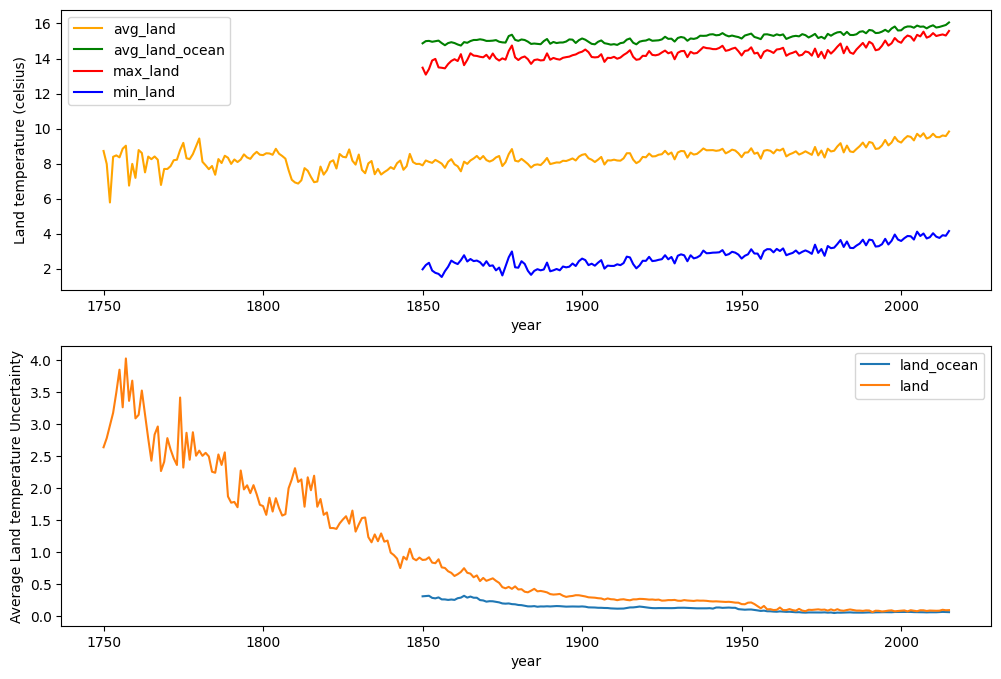

In [7]:
# GLOBAL TEMPERATURES group by year
sql = "select YEAR(dt) as year, AVG(landaveragetemperature) as land_temp," \
"AVG(landandoceanaveragetemperature) as land_ocean_temp," \
"AVG(landandoceanaveragetemperatureuncertainty) as land_ocean_uncertainty," \
"AVG(landaveragetemperatureuncertainty) as land_temp_uncertainty, " \
"AVG(landmaxtemperature) as land_temp_max," \
"AVG(landmintemperature)  as land_temp_min " \
"FROM globaltemperatures group by YEAR(dt) order by year"
df = pd.read_sql(sql, engine)

date = df['year']
land_avg_temp = df['land_temp']
land_temp_max = df['land_temp_max']
land_temp_min= df['land_temp_min']
landocean_avg_temp = df['land_ocean_temp']
landocean_avg_temp_uncertainty = df['land_ocean_uncertainty']
land_avg_temp_uncertainty = df['land_temp_uncertainty']

plt.figure(figsize=(12, 8))
plt.subplot(211)
plt.plot(date, land_avg_temp, color = 'orange', label = 'avg_land')
plt.plot(date, landocean_avg_temp, color = 'g', label = 'avg_land_ocean')
plt.plot(date, land_temp_max, color='r', label = 'max_land')
plt.plot(date, land_temp_min, color='b', label = 'min_land')
plt.legend(loc='upper left')
plt.ylabel('Land temperature (celsius)')
plt.xlabel('year')

plt.subplot(212)
plt.plot(date, landocean_avg_temp_uncertainty, label='land_ocean')
plt.plot(date, land_avg_temp_uncertainty , label = 'land')
plt.legend()
plt.ylabel('Average Land temperature Uncertainty')
plt.xlabel('year')

df.head()

De eerdere data heeft een grotere spreiding. Is mogelijk ook door de hogere onzekerheid in deze data. Land en oceaan gemiddelde temperatuur liggen over het algemeen hoger dan alleem land gemiddelde. 

#### 4.2.i Country dataset
- vergelijk de gemiddelde temperatuur over verschillende landen
- identificeer landen met de hoogste en laagste gemiddelde temperatuur
- visualiseer deze landen om verschillen te zien

In [8]:
sql = "select * from globaltempcountry"
df = pd.read_sql(sql, engine)
df.head()

,id,dt,AverageTemperature,AverageTemperatureUncertainty,country_id
0,1,1743-11-01,4.384,2.294,1
1,2,1743-12-01,NaN,NaN,1
2,3,1744-01-01,NaN,NaN,1
3,4,1744-02-01,NaN,NaN,1
4,5,1744-03-01,NaN,NaN,1


In [9]:
sql = "select * from country"
df_country = pd.read_sql(sql,engine)
df_country['id'].to_list()

country_names = []
temp_list = []
for index, row in df_country.iterrows():
    id = row['id']
    country_names.append(row['name'])

    sql = f"select averagetemperature as temp from globaltempcountry where country_id = {id}"
    df = pd.read_sql(sql, engine)
    temp_list.append(df['temp'].dropna().to_numpy())



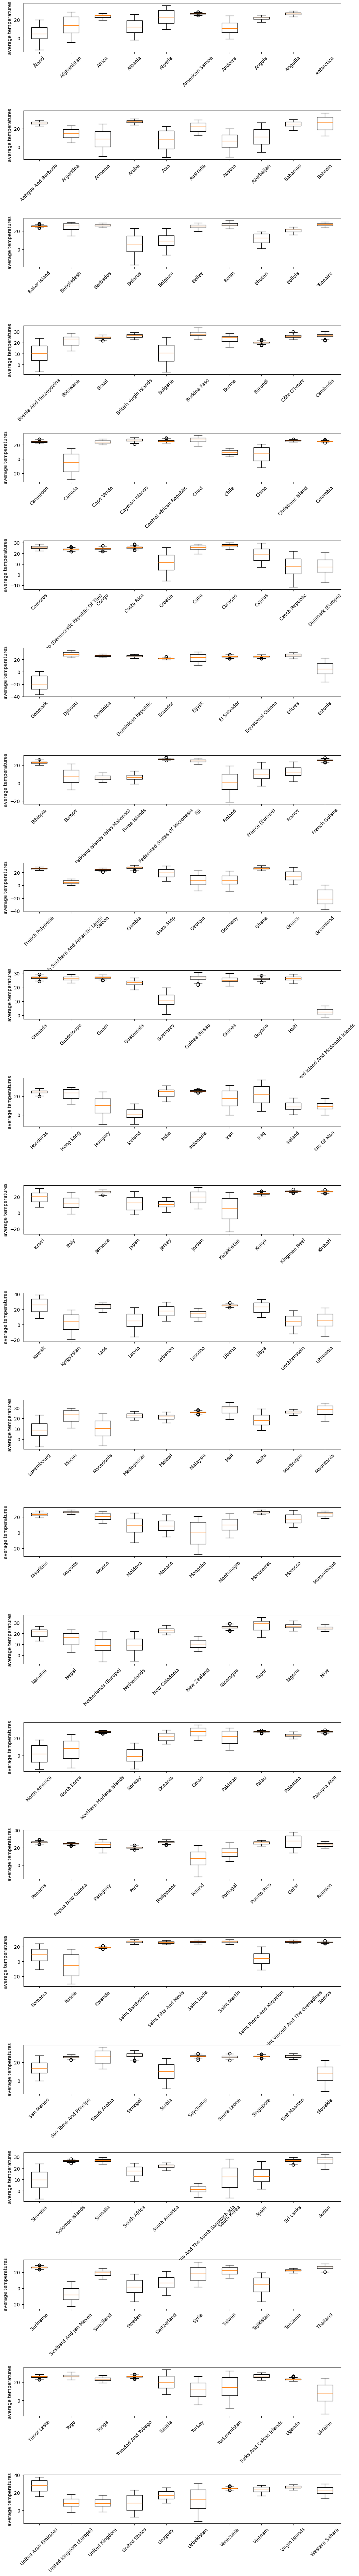

In [10]:
plt.figure(figsize=[12,100])

istart = 0
istop = 10

for i in range(1,25):
    plt.subplot(25,1,i)

    plt.boxplot(temp_list[istart:istop], tick_labels=country_names[istart:istop])
    plt.xticks(rotation=45)
    # plt.xlabel(country_names[istart:istop])
    plt.subplots_adjust(hspace=1.2) 
    plt.ylabel('average temperatures')
    istart += 10
    istop += 10


Top 10 countries with highest average temperatures
     max_temp          dt                  name
120    38.842  1839-12-01                Kuwait
230    37.750  1843-01-01  United Arab Emirates
178    37.603  1843-01-01                 Qatar
19     37.471  1843-01-01               Bahrain
107    37.401  1819-01-01                  Iraq
192    36.495  1843-01-01          Saudi Arabia
4      35.829  1787-01-01               Algeria
136    35.330  1849-01-01                  Mali
61     35.175  1864-01-01              Djibouti
165    35.096  1843-01-01                  Oman

 Top 10 countries with lowest average temperatures
     min_temp          dt                    name
89    -37.658  1823-01-01               Greenland
60    -36.830  1823-01-01                 Denmark
181   -30.577  1812-01-01                  Russia
41    -28.736  1768-09-01                  Canada
145   -27.442  1820-08-01                Mongolia
116   -23.601  1812-01-01              Kazakhstan
211   -22.587  1761

Text(0, 0.5, 'max average temperature')

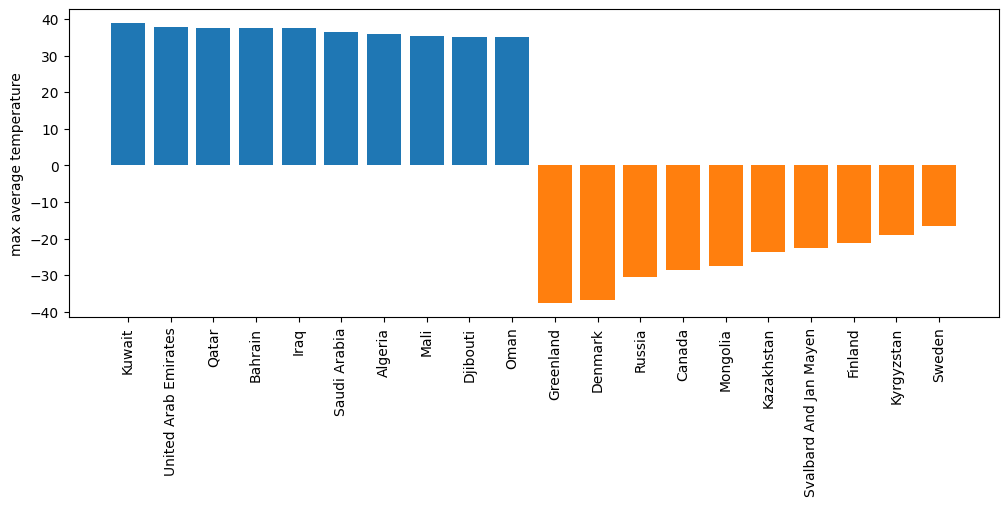

In [11]:
"""
Show top 10 countries with highest or lowest temperatures ever
"""
# countries with highest average temperatures
sql = 'select max(averageTemperature) as max_temp,dt, country_id from globaltempcountry group by country_id'
df = pd.read_sql(sql, engine)
df.head()

df_maxtemp_country = df.merge(df_country, left_on="country_id", right_on="id").drop(columns=['country_id', 'id'])
df_maxtemp_country  = df_maxtemp_country.sort_values('max_temp', ascending=False ).head(10)
print('Top 10 countries with highest average temperatures')
print(df_maxtemp_country)

# countries with lowest average temperatures
sql = 'select min(averageTemperature) as min_temp,dt, country_id from globaltempcountry group by country_id'
df = pd.read_sql(sql, engine)
df.head()

df_mintemp_country = df.merge(df_country, left_on="country_id", right_on="id").drop(columns=['country_id', 'id'])
df_mintemp_country = df_mintemp_country.sort_values('min_temp' ).head(10)
print('\n Top 10 countries with lowest average temperatures')
print(df_mintemp_country)

plt.figure(figsize=[12,4])

plt.bar(df_maxtemp_country['name'][0:10], df_maxtemp_country['max_temp'][0:10])
plt.xticks(rotation=90)
plt.ylabel('max average temperature')

plt.bar(df_mintemp_country['name'][0:10], df_mintemp_country['min_temp'][0:10])
plt.xticks(rotation=90)
plt.ylabel('max average temperature')

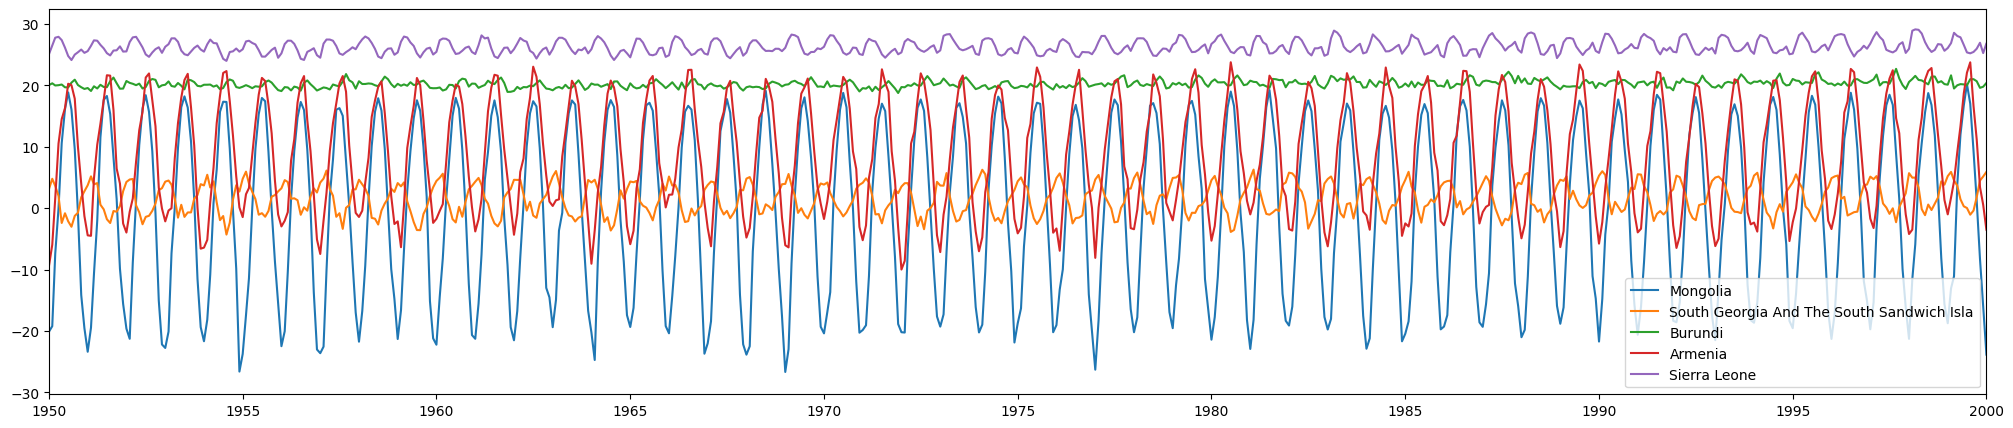

In [12]:
"""
Plot average temperature for 5 random countries over 50 years of time
"""

plt.figure(figsize= [25,5])
plt.subplot()
indices = rand.sample(range(0, len(df_country)), 5)

for i_row in indices:
    country_name = df_country.iloc[i_row]['name']
    id = df_country.iloc[i_row]['id']

    sql = sql = f"select dt, averagetemperature as temp from globaltempcountry where country_id = {id}"
    df = pd.read_sql(sql, engine).dropna()
    df['dt'] = pd.to_datetime(df['dt'])
    plt.plot(df['dt'], df['temp'],label = country_name)

plt.xlim(pd.Timestamp("1950-01-01"), pd.Timestamp("2000-01-01"))
plt.legend()


Duidelijke trend dat ieder jaar de temperatuur stijgt en weer daalt. De landen op zuidelijkhalfrond verschillen ongeveer een halve fase met de landen  op het noordelijk halfrond zoals verwacht. OOk zijn de verschillen in temperatuur kleiner in landen korter by de evenaar. 

#### 4.2.ii (major) City dataset
- Analyseer de temperatuur trends in steden en vergelijk ze.
- Identificeer de steden met de grootste verschillen in temperatuur.
- Visualiseer de temperatuur veranderingen voor deze specifieke steden over de tijd

In [13]:
# major city table -> has 108 cities
sql = 'select A.id, A.name from city as A ' \
'join globaltempmajorcity as B ' \
'on A.id = B.city_id ' \
'GROUP BY A.id'
df_majorcity = pd.read_sql(sql,engine)

print(len(df_majorcity))
df_majorcity.head()

108


,id,name
0,18,Abidjan
1,33,Addis Abeba
2,46,Ahmadabad
3,75,Aleppo
4,76,Alexandria


In [14]:
sql = 'select * from globaltempmajorcity'
df = pd.read_sql(sql,engine)
df.head()

,id,dt,averagetemperature,averagetemperatureuncertainty,city_id,latitude,longitude
0,1,1849-01-01,26.704,1.435,18,5.63N,3.23W
1,2,1849-02-01,27.434,1.362,18,5.63N,3.23W
2,3,1849-03-01,28.101,1.612,18,5.63N,3.23W
3,4,1849-04-01,26.140,1.387,18,5.63N,3.23W
4,5,1849-05-01,25.427,1.200,18,5.63N,3.23W


In [15]:
# boxplot of all avg temperatures per city
majorcity_names = []
temp_list = []
for index, row in df_majorcity.iterrows():
    id = row['id']
    majorcity_names.append(row['name'])

    sql = f"select averagetemperature as temp from globaltempmajorcity where city_id = {id}"
    df = pd.read_sql(sql, engine)
    temp_list.append(df['temp'].dropna().to_numpy())

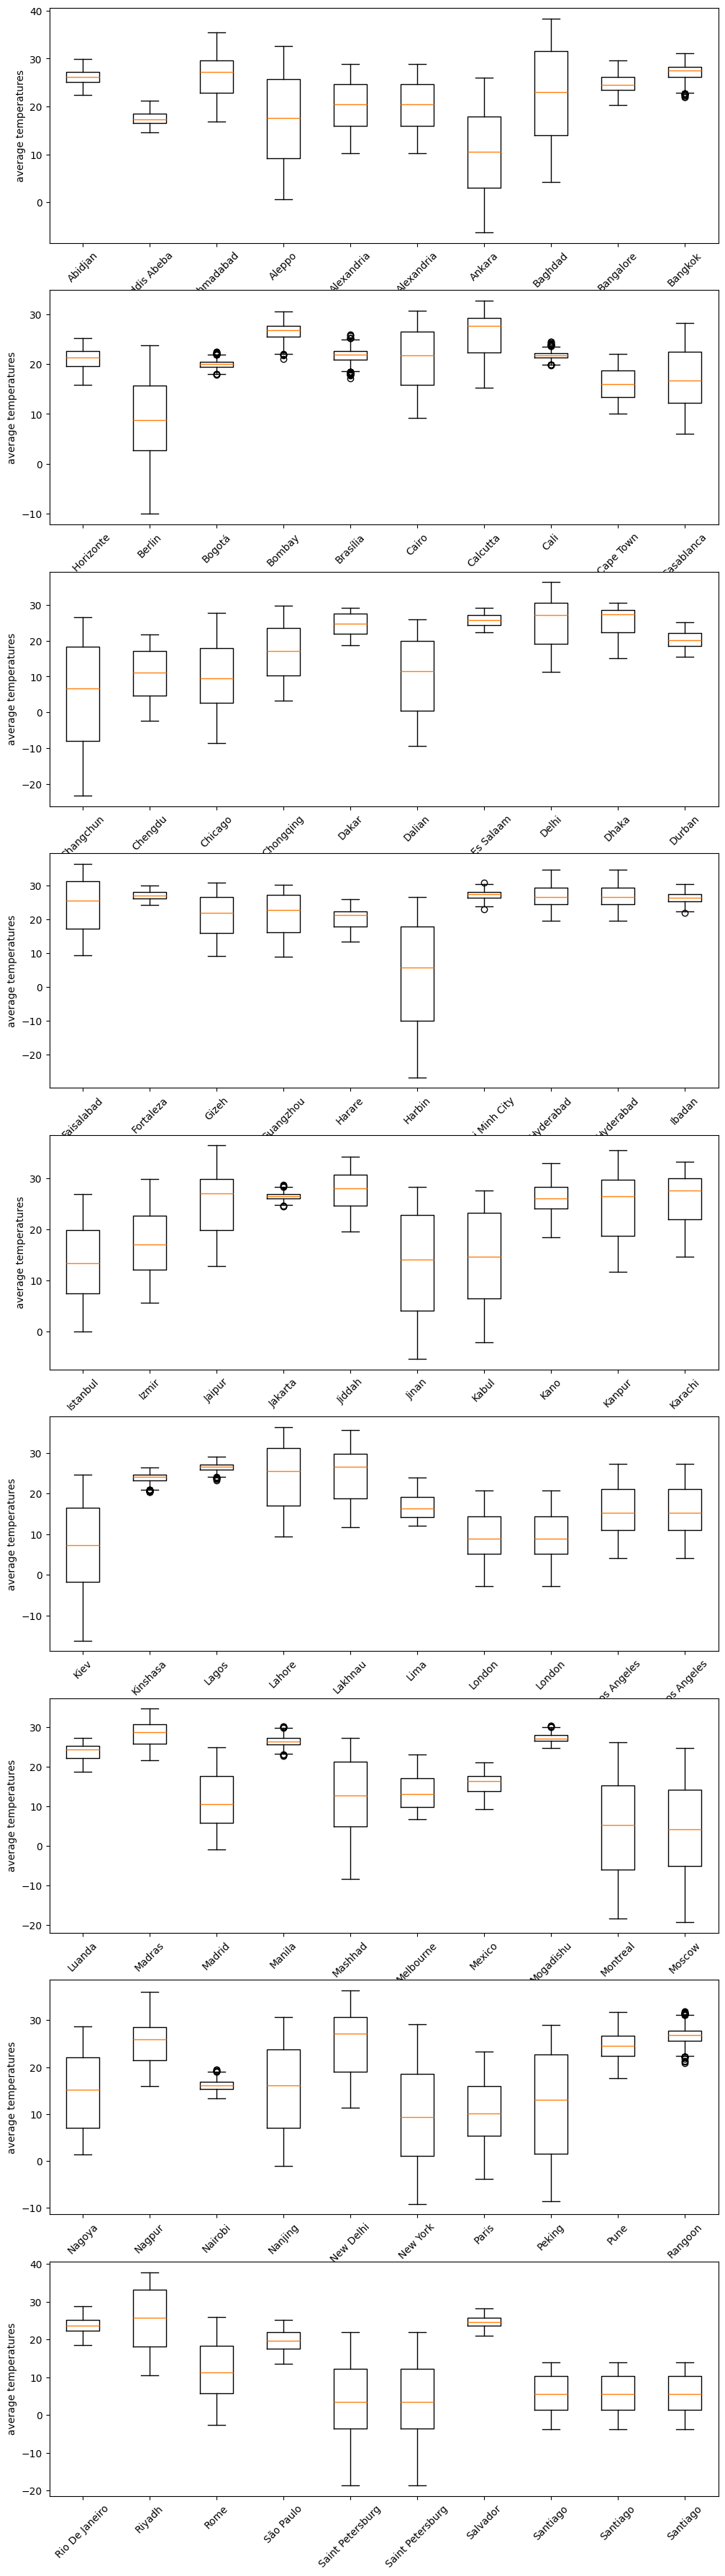

In [16]:
plt.figure(figsize=[12,50])

istart = 0
istop = 10

for i in range(1,10):
    plt.subplot(10,1,i)

    plt.boxplot(temp_list[istart:istop], tick_labels=majorcity_names[istart:istop])
    plt.xticks(rotation=45)
    # plt.xlabel(country_names[istart:istop])
    # plt.subplots_adjust(hspace=1.2) 
    plt.ylabel('average temperatures')
    istart += 10
    istop += 10

(np.float64(-7305.0), np.float64(10957.0))

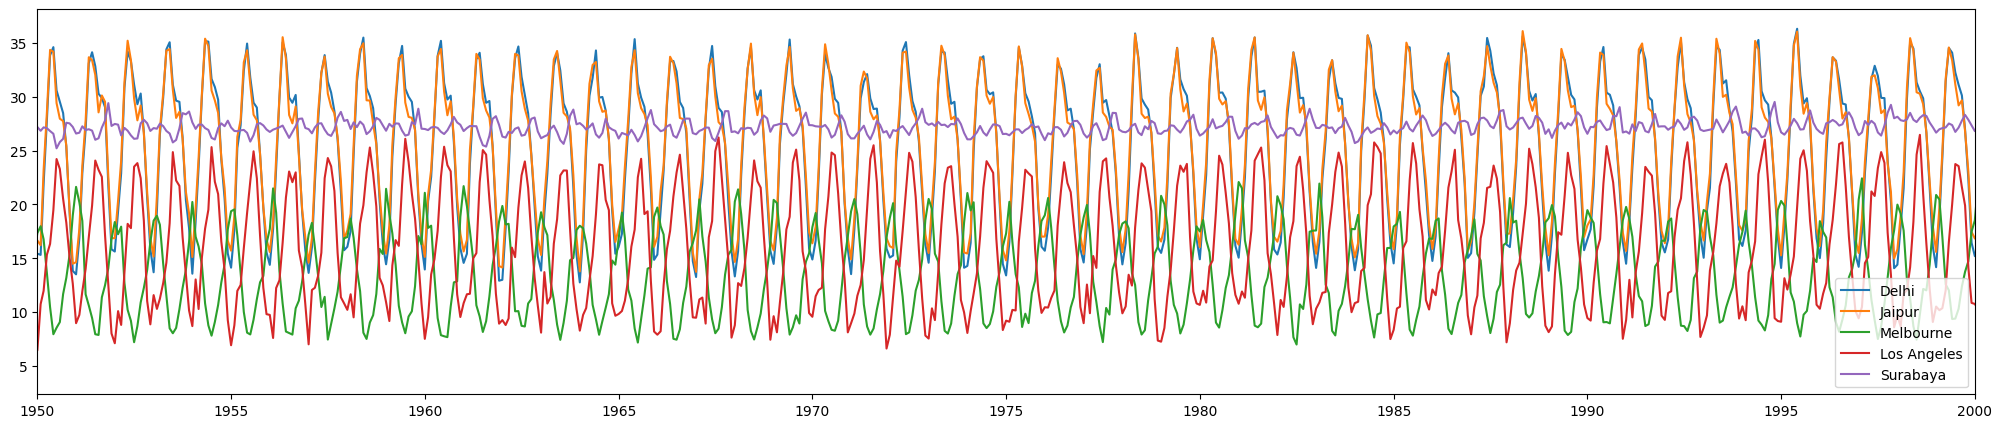

In [17]:
"""
Plot average temperature for 5 random countries over 50 years of time
"""

plt.figure(figsize= [25,5])
plt.subplot()
indices = rand.sample(range(0, len(df_majorcity)), 5)

for i_row in indices:
    city_name = df_majorcity.iloc[i_row]['name']
    id = df_majorcity.iloc[i_row]['id']

    sql = sql = f"select dt, averagetemperature as temp from globaltempmajorcity where city_id = {id}"
    df = pd.read_sql(sql, engine).dropna()
    df['dt'] = pd.to_datetime(df['dt'])
    plt.plot(df['dt'], df['temp'],label = city_name)

plt.legend()
plt.xlim(pd.Timestamp("1950-01-01"), pd.Timestamp("2000-01-01"))



In [18]:
# find cities with largest differences
sql = 'select MIN(averagetemperature) as min_temp, MAX(averagetemperature) max_temp, AVG(averagetemperature) as avg_temp, city_id from globaltempmajorcity group by city_id'
df = pd.read_sql(sql, engine)
df['diff'] = df['max_temp']- df['min_temp']
df = df.merge(df_majorcity, left_on = "city_id", right_on = "id")
df = df.drop(columns= ['id'])
df = df.sort_values('diff', ascending = False)
df_diff = df.head(10)
df_diff

,min_temp,max_temp,avg_temp,city_id,diff,name
35,-26.772,26.509,3.625744,1155,53.281,Harbin
20,-23.272,26.572,4.923798,582,49.844,Changchun
68,-18.363,26.164,4.445014,2009,44.527,Montreal
69,-19.376,24.580,3.999711,2022,43.956,Moscow
94,-17.035,26.010,7.214980,2824,43.045,Shenyang
104,-15.502,25.649,5.773911,3130,41.151,Toronto
50,-16.191,24.593,7.041033,1554,40.784,Kiev
85,-18.644,21.921,3.918045,2658,40.565,Saint Petersburg
84,-18.644,21.921,3.918045,2657,40.565,Saint Petersburg
75,-9.162,29.141,9.523296,2124,38.303,New York


Text(0, 0.5, 'Temperature ($^circ$C)')

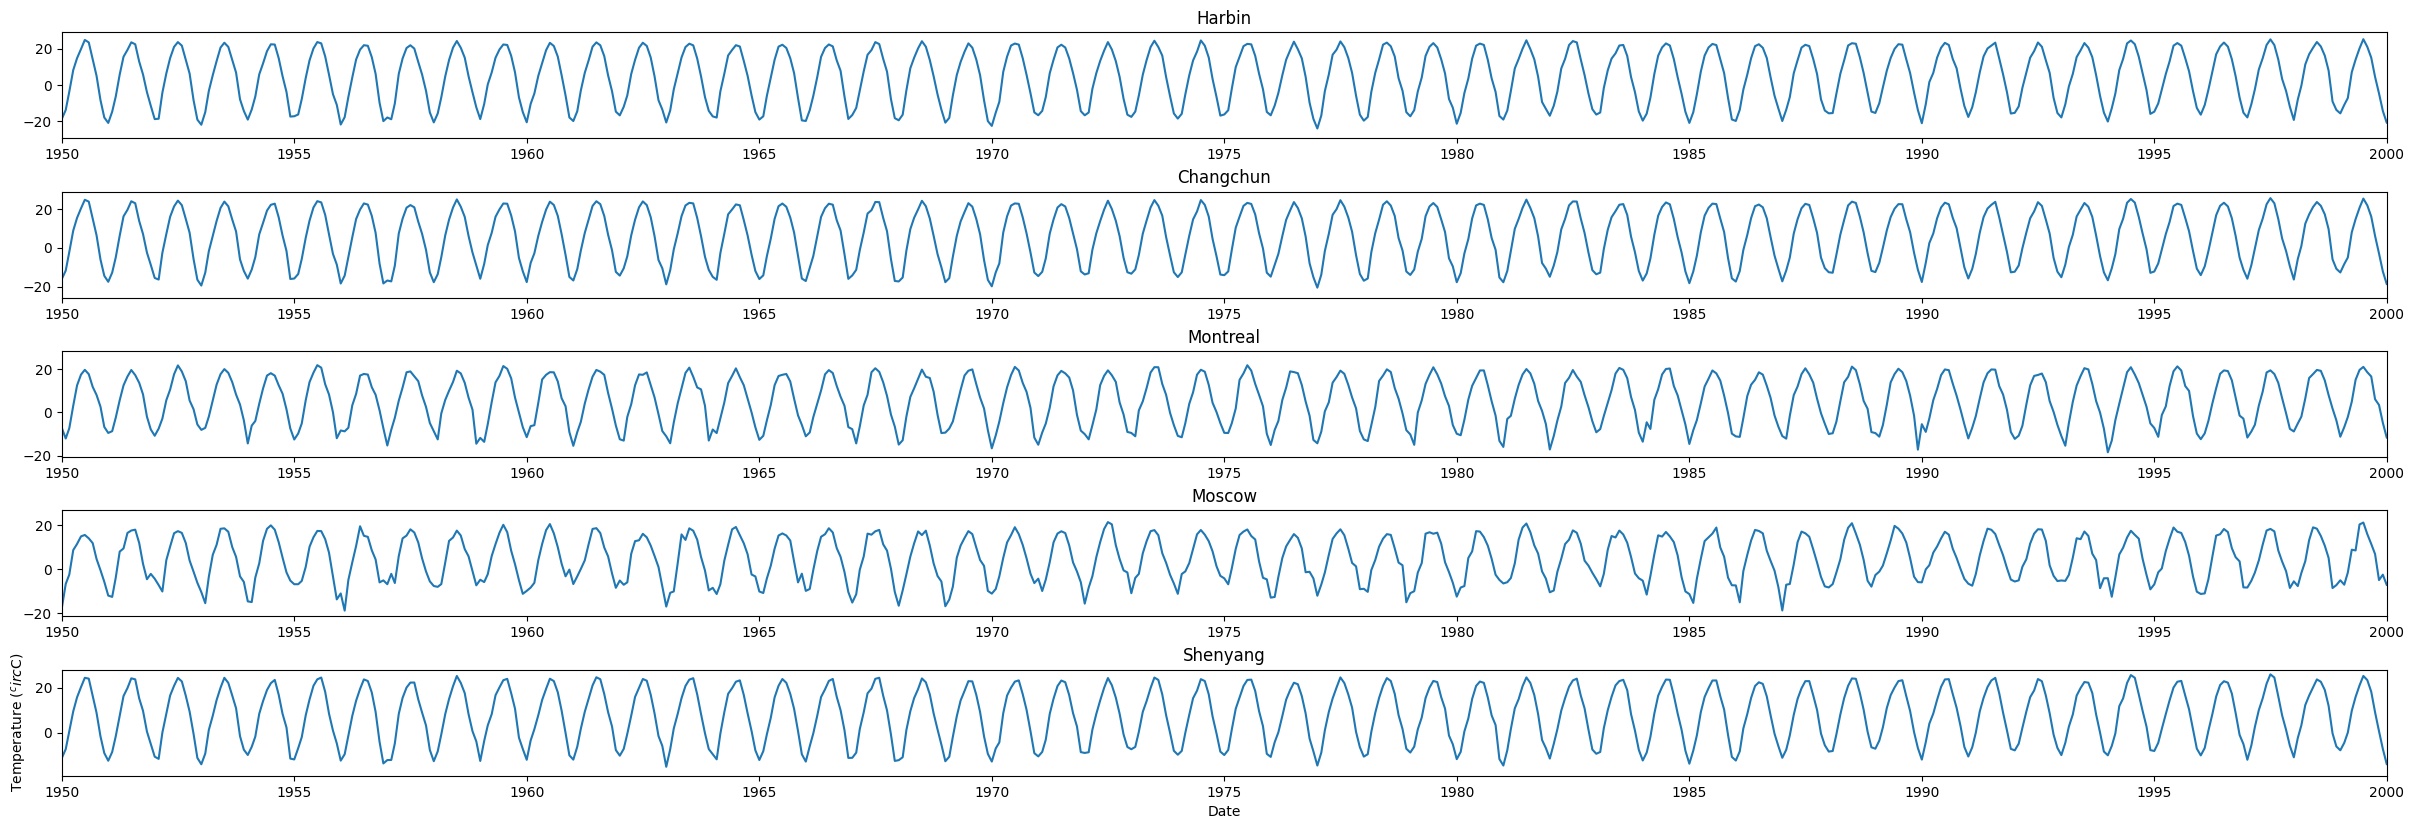

In [19]:
# temperature changes for cities with biggest differences

plt.figure(figsize= [30,20])
city_ids = df_diff['city_id'].to_list()
city_names = df_diff['name'].to_list()

for i in range(5):
    id = city_ids[i]
    name = city_names[i]

    sql = f"select dt, averagetemperature as temp from globaltempmajorcity where city_id = {id}"
    df = pd.read_sql(sql, engine).dropna()  
    df['dt'] = pd.to_datetime(df['dt'])

    plt.subplot(10,1,i+1)
    plt.subplots_adjust(hspace=0.5) 
    plt.plot(df['dt'], df['temp'],label = name)
    plt.title(name)
    plt.xlim(pd.Timestamp("1950-01-01"), pd.Timestamp("2000-01-01"))

plt.xlabel('Date')
plt.ylabel('Temperature ($^circ$C)')

#### 3. Uncertainty Analysis
- Gebruik de uncertainty waardes in de globaltemperatures data om uit te vinden waar of wanneer de uncertainty hoog of laag is.
- Is er een verband tussen uncertainty en tijd. (bijvoorbeeld wordt uncertainty kleiner hoe recenter de data is)
- Vergelijk uncertainty in land en ocean temperatures

Hoe ouder de data hoe groter de onzekerheid. land + ocean temperatuurmetinge hebben minder onzerheid. Dit zou kunnen komen omdat deze waarde ook stabieler zijn. 

In [20]:
# Get uncertainty values from global temperarues 
sql = "SELECT dt, LandAverageTemperatureUncertainty as land_uncertainty, LandMaxTemperatureUncertainty as land_max_uncertainty, LandMinTemperatureUncertainty as land_min_uncertainty," \
" LandAndOceanAverageTemperatureUncertainty as land_ocean_uncertainty FROM globaltemperatures"
df = pd.read_sql(sql, engine)
df.head()
max(df['dt'])

datetime.date(2015, 12, 1)

(0.0, 0.6)

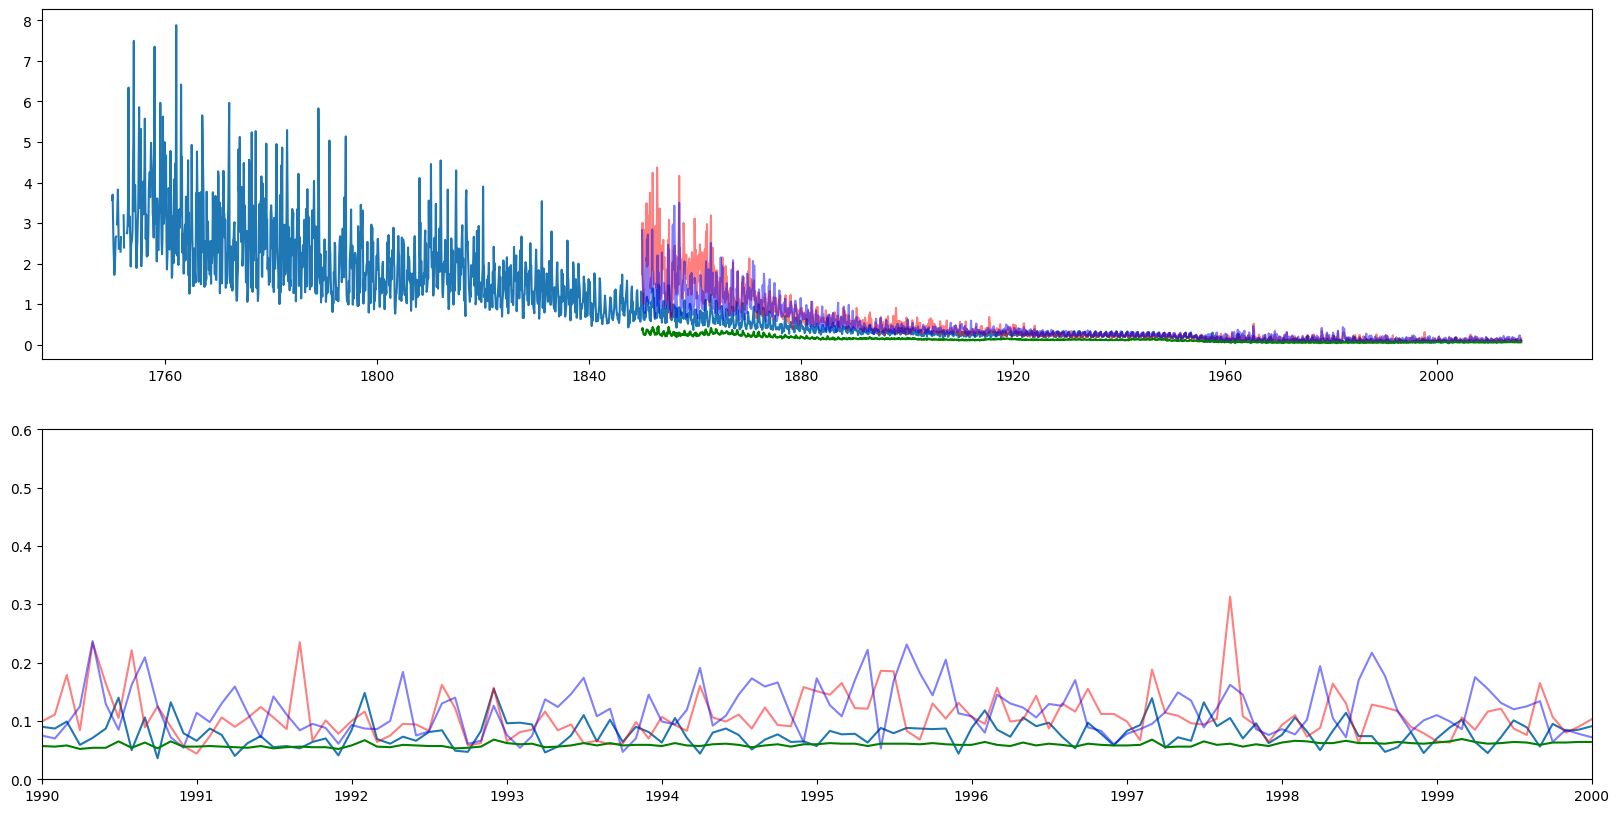

In [21]:
plt.figure(figsize=[20,10])
land_uncertainty = df['land_uncertainty']
land_max_uncertainty = df['land_max_uncertainty']
land_min_uncertainty = df['land_min_uncertainty']
land_ocean_uncertainty = df['land_ocean_uncertainty']
dt = df['dt']

plt.subplot(2,1,1)
plt.plot(dt, land_uncertainty)
plt.plot(dt, land_max_uncertainty, color = 'r', alpha=0.5)
plt.plot(dt, land_min_uncertainty, color = 'b', alpha=0.5)
plt.plot(dt, land_ocean_uncertainty, color = 'green')

plt.subplot(2,1,2)
plt.plot(dt, land_uncertainty)
plt.plot(dt, land_max_uncertainty, color = 'r', alpha=0.5)
plt.plot(dt, land_min_uncertainty, color = 'b', alpha=0.5)
plt.plot(dt, land_ocean_uncertainty, color = 'green')
plt.xlim(pd.Timestamp("1990-01-01"), pd.Timestamp("2000-01-01"))
plt.ylim(0,0.6)

#### 4. Geospatial analysis
- Maak gebruik van lengte- en breedtegraad waardes (namen van landen kan ook)
- Gebruik een package zoals plotly.express en een plot zoals de scatter.geo met lengte- en breedtegraad waardes of choropleth met landen / regio's om trends op de wereldkaart te laten zien.

In [85]:
#
sql = 'select AVG(averagetemperature) as avg_temp, max(averagetemperature) as max_temp, min(averagetemperature) as min_temp,latitude, longitude from globaltempcity group by city_id'
df = pd.read_sql(sql,engine)

lon = []
for row in df['longitude']:
    coord = float(row[:-1])
    if row[-1] == 'W':
        coord = coord*-1
    lon.append(coord)

df['longitude'] = lon
lat = [float(row[:-1]) for row in df['latitude']]
df['latitude'] = lat
df.head()


,avg_temp,max_temp,min_temp,latitude,longitude
0,13.276619,36.856,-30.421,24.92,120.59
1,7.695135,20.883,-7.816,57.05,10.33
2,13.319012,26.891,-0.966,40.99,27.69
3,9.957553,24.746,-6.127,40.99,34.08
4,1.308672,22.229,-28.720,50.63,82.39


In [90]:
plot = px.scatter_geo(df, lat="latitude", lon='longitude', color= "avg_temp", color_continuous_scale="icefire")
plot.update_layout(title = {'text':'Average temperature per city', 'x':0.5})

In [91]:
plot = px.scatter_geo(df, lat="latitude", lon='longitude', color= "max_temp", color_continuous_scale="hot" )
plot.update_layout(title = {'text':'Average temperature per city', 'x':0.5})

In [92]:
plot = px.scatter_geo(df, lat="latitude", lon='longitude', color= "min_temp", color_continuous_scale="blues" )
plot.update_layout(title = {'text':'Average temperature per city', 'x':0.5})

#### POWER BI
Exporteer de berekende dataframes naar afzonderlijke CSV bestanden. Maak met behulp van Power BI een dashboard dat de trendlijnen van deze data visualiseert.

In [98]:
# sql = 'select * from ' + table_name
# df = read_sql(sql, engine)
# df.to_csv('Climate_data/'+ table_name)
inspector = SA.inspect(engine)
table_names = inspector.get_table_names()

for table_name in table_names:
    sql = 'select * from ' + table_name
    df = pd.read_sql(sql, engine)
    path = 'Climatedata/'+ table_name +'.csv'
    succes = df.to_csv(path)
    print(table_name, ':', succes)


city : None
country : None
globaltempcity : None
globaltempcountry : None
globaltemperatures : None
globaltempmajorcity : None
globaltempstate : None
state : None
